# **Implementación del caso de 5 Qubits**

In [110]:
%load_ext autoreload
%autoreload 2

import modules
from modules.Schnorr_QAOA import SchnorrAlgQAOA


import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [111]:
seed = 99

In [112]:
N5 = 48567227

In [113]:
fiveQubit = SchnorrAlgQAOA(N5, 4, 1, seed)

El numero de bits de N = 48567227 es m = 26
La dimension del reticulo que vamos a tratar es n = 5
La cota smooth que vamos a tomar: 25


In [114]:
#fiveQubit.set_smoothbound(50)

In [115]:
B5, t5 = fiveQubit.generate_cvp(10)
print(f'B5 = \n{B5}')
print(f't5 = \n{t5}')

B5 = 
[ 2 0 0 0 0  6931 ]
[ 0 1 0 0 0 10986 ]
[ 0 0 3 0 0 16094 ]
[ 0 0 0 2 0 19459 ]
[ 0 0 0 0 1 23979 ]
t5 = 
(0, 0, 0, 0, 0, 176985)


In [116]:
D5, b5_op, res5_vector, sign_step5, w5, dist5 = fiveQubit.babai_algorithm(B5, t5, delta = 0.99)
print(f'D5 = \n{D5}\n')
print(f'b5_op = \n{b5_op}\n')
print(f'res5_vector = \n{res5_vector}\n')
print(f'sign_step5 = \n{sign_step5}\n')
print(f'w5 = \n{w5}\n')
print(f'dist5 = \n{dist5}\n')

D5 = 
[  6 -4  6  4 -2  -3 ]
[ -8 -3  6 -2  2   5 ]
[  2 11  3  0 -6  -3 ]
[ -4 -5  0 12 -2   4 ]
[ -4 -3 -3  4  1 -17 ]

b5_op = 
[     2      4      9      8      0 176993]

res5_vector = 
[-2 -4 -9 -8  0 -8]

sign_step5 = 
[-1 -1 -1 -1  1]

w5 = 
(-3092, -354, -1837, 3883, -8732)

dist5 = 
15.132745950421556



In [117]:
qubo5 = fiveQubit.define_qubo(D5, res5_vector, sign_step5)
print(qubo5.prettyprint())
Hc5, offset5 = fiveQubit.define_hamiltonian(qubo5)
print(f'Offset = {offset5}')
print(f'Hamiltonian = \n{Hc5}')

Problem name: quboProblem

Minimize
  117*z_0^2 - 54*z_0*z_1 + 14*z_0*z_2 + 72*z_0*z_3 - 70*z_0*z_4 + 142*z_1^2
  - 116*z_1*z_2 + 78*z_1*z_3 + 136*z_1*z_4 + 179*z_2^2 - 126*z_2*z_3
  + 10*z_2*z_4 + 205*z_3^2 - 18*z_3*z_4 + 340*z_4^2 - 116*z_0 - 100*z_1
  - 102*z_2 - 200*z_3 - 302*z_4 + 229

Subject to
  No constraints

  Binary variables (5)
    z_0 z_1 z_2 z_3 z_4

Offset = 292.0
Hamiltonian = 
SparsePauliOp(['IIIIZ', 'IIIZI', 'IIZII', 'IZIII', 'ZIIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[  9. +0.j, -32. +0.j,  16. +0.j,  -4. +0.j, -33.5+0.j, -13.5+0.j,
   3.5+0.j,  18. +0.j, -17.5+0.j, -29. +0.j,  19.5+0.j,  34. +0.j,
 -31.5+0.j,   2.5+0.j,  -4.5+0.j])


In [118]:
formatted_h = " + ".join([f"{c.real:.3f}{s}" for s, c in Hc5.label_iter()])
print(formatted_h)

9.000IIIIZ + -32.000IIIZI + 16.000IIZII + -4.000IZIII + -33.500ZIIII + -13.500IIIZZ + 3.500IIZIZ + 18.000IZIIZ + -17.500ZIIIZ + -29.000IIZZI + 19.500IZIZI + 34.000ZIIZI + -31.500IZZII + 2.500ZIZII + -4.500ZZIII


In [119]:
circuit5 = fiveQubit.construct_circuit(Hc5, reps= 1)
print(circuit5.decompose(reps = 2))

     ┌────────────┐ ┌─────────────┐                                »
q_0: ┤ U(π/2,0,π) ├─┤ Rz(18*γ[0]) ├───■────────────────■───────────»
     ├────────────┤┌┴─────────────┴─┐ │ZZ((-27)*γ[0])  │           »
q_1: ┤ U(π/2,0,π) ├┤ Rz((-64)*γ[0]) ├─■────────────────┼───────────»
     ├────────────┤└┬─────────────┬─┘                  │ZZ(7*γ[0]) »
q_2: ┤ U(π/2,0,π) ├─┤ Rz(32*γ[0]) ├────────────────────■───────────»
     ├────────────┤┌┴─────────────┴┐                               »
q_3: ┤ U(π/2,0,π) ├┤ Rz((-8)*γ[0]) ├───────────────────────────────»
     ├────────────┤├───────────────┴┐                              »
q_4: ┤ U(π/2,0,π) ├┤ Rz((-67)*γ[0]) ├──────────────────────────────»
     └────────────┘└────────────────┘                              »
«                                                                   »
«q_0: ──────────────────■───────────────────────────■───────────────»
«                       │                           │               »
«q_1: ─■────────────────┼──────

In [120]:
x0 = np.asarray([0.0]*circuit5.num_parameters)
optParameters10 = fiveQubit.qaoa_algorithm(circuit5, Hc5, x0)

In [121]:
for param in optParameters10.items():
    print(f'{param[0].name} = {param[1]}')

β[0] = 0.38312632010753533
γ[0] = -0.010041903424999107


In [122]:
results5= fiveQubit.sample_from_parameters(circuit5, optParameters10, shots = 10_000)
print(len(results5))
for bitstring, count in results5.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

32
Bistring: 01100 -> Counts: 1068
Bistring: 00111 -> Counts: 1039
Bistring: 10001 -> Counts: 1024
Bistring: 01110 -> Counts: 691
Bistring: 00001 -> Counts: 642
Bistring: 11101 -> Counts: 623
Bistring: 00000 -> Counts: 589
Bistring: 11100 -> Counts: 558
Bistring: 00011 -> Counts: 541
Bistring: 01111 -> Counts: 492
Bistring: 00110 -> Counts: 428
Bistring: 01000 -> Counts: 422
Bistring: 01101 -> Counts: 250
Bistring: 11001 -> Counts: 245
Bistring: 11000 -> Counts: 226
Bistring: 10000 -> Counts: 182
Bistring: 10111 -> Counts: 181
Bistring: 00010 -> Counts: 158
Bistring: 10101 -> Counts: 138
Bistring: 00101 -> Counts: 107
Bistring: 11111 -> Counts: 78
Bistring: 01001 -> Counts: 75
Bistring: 00100 -> Counts: 68
Bistring: 11010 -> Counts: 36
Bistring: 11011 -> Counts: 31
Bistring: 10010 -> Counts: 27
Bistring: 01010 -> Counts: 17
Bistring: 11110 -> Counts: 15
Bistring: 10011 -> Counts: 15
Bistring: 10100 -> Counts: 12
Bistring: 01011 -> Counts: 12
Bistring: 10110 -> Counts: 10


In [123]:
nD5 = fiveQubit.integer_to_matrix(D5)
vnew5 = fiveQubit.bitstring2latticeVectors(nD5, results5.keys(), sign_step5, b5_op)
for vect5 in vnew5:
    print(vect5)

[     4     -2      6     -4      8 176992]
[     2      0     -6      6      6 176994]
[    -8      5      0      8      3 176979]
[    12      1      0     -2      6 176987]
[    -4      8      3      4      2 176996]
[    -6     -1     -3     -4     11 176978]
[     2      4      9      8      0 176993]
[     0     -5      3      0      9 176975]
[     4     11     -3      6      0 176991]
[     6      5     -6     -6      8 176990]
[     8     -4      0     10      4 176991]
[     6      9      9     -4      2 176989]
[    -2      2      0     -8     10 176995]
[    -4     10      0     -4      5 176975]
[     2      6      6      0      3 176972]
[    -2      1      6     12      1 176976]
[    -2     -3     -9     10      7 176977]
[    10      7      3     10     -2 176988]
[   -10     -6     -3      8      9 176982]
[    -6     -3      0      4      8 176999]
[     2      2     -9     -2      9 176973]
[     0     13      3     -8      4 176992]
[     0     -7      6      8    

In [124]:
distances5 = fiveQubit.get_distances(vnew5, t5)
for dist in distances5:
    print(f"{dist:.3f}")

13.601
13.892
14.071
13.748
15.166
15.232
15.133
14.663
14.765
14.900
15.232
15.297
16.492
16.031
15.937
16.340
17.521
16.462
17.292
17.916
17.833
17.521
17.493
22.583
21.424
21.095
18.815
18.841
17.944
18.815
19.313
20.396


In [125]:
nB5 = fiveQubit.integer_to_matrix(B5)
uv_pairs5 = fiveQubit.vectors2uv_pairs(nB5, vnew5)
for pair5 in uv_pairs5:
    print(pair5)

[21435888100 441]
[1215290846 25]
[776562633 16]
[340139712 7]
[194500845 4]
[285311670611 5880]
[48620250 1]
[11789738455 243]
[243045684 5]
[416713664664 8575]
[3937140592 81]
[2381643000 49]
[233436821409 4802]
[9509900499 196]
[48514950 1]
[97060425 2]
[327520882997 6750]
[5881105440 121]
[5661432406091 116640]
[10503585169 216]
[42443058438 875]
[116712415215 2401]
[106337949025 2187]
[48498912 1]
[8488175652 175]
[533655864 11]
[340122240 7]
[2182563152 45]
[1212977997 25]
[11463230904895 236196]
[83338451856 1715]
[530529694772 10935]


In [126]:
sr_pairs5 = fiveQubit.uv_pairs2sr_pairs(uv_pairs5)
print(sr_pairs5)

[(11789738455, 243)]


In [127]:
probs5 = fiveQubit.get_probs(results5.values(), shots = 10_000)

In [128]:
fiveQubit.prettyprint(vnew5, distances5, probs5, b5_op, t5, res5_vector, dist5)

Vector más corto por algoritmo de Babai: 
b_op = [     2      4      9      8      0 176993]

El vector residual 
t - b_op = [-2 -4 -9 -8  0 -8]

La distancia |t - b_op| = 15.133

0: Prob = 0.10680
	vnew = [     4     -2      6     -4      8 176992] con distancia: 13.601
1: Prob = 0.10390
	vnew = [     2      0     -6      6      6 176994] con distancia: 13.892
2: Prob = 0.10240
	vnew = [    -8      5      0      8      3 176979] con distancia: 14.071
3: Prob = 0.06910
	vnew = [    12      1      0     -2      6 176987] con distancia: 13.748
4: Prob = 0.06420
	vnew = [    -4      8      3      4      2 176996] con distancia: 15.166
5: Prob = 0.06230
	vnew = [    -6     -1     -3     -4     11 176978] con distancia: 15.232
6: Prob = 0.05890
	vnew = [     2      4      9      8      0 176993] con distancia: 15.133
7: Prob = 0.05580
	vnew = [     0     -5      3      0      9 176975] con distancia: 14.663
8: Prob = 0.05410
	vnew = [     4     11     -3      6      0 176991] con distancia:

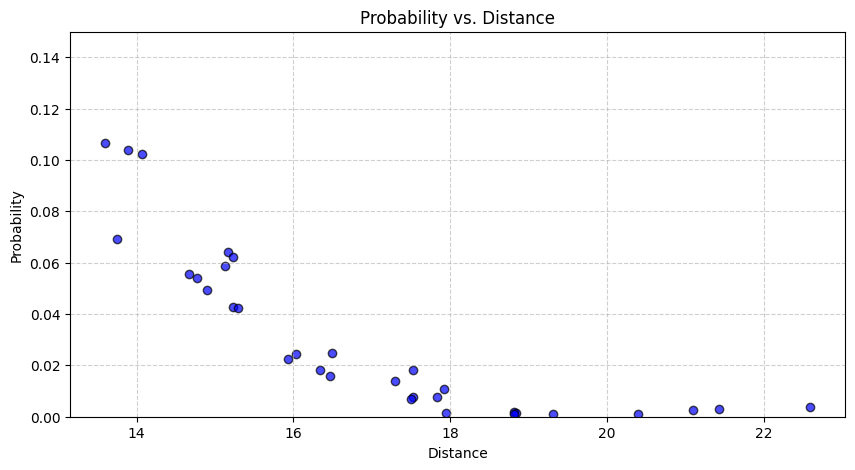

In [129]:
plt.figure(figsize=(10, 5))

# Creating the scatter plot
plt.scatter(distances5, probs5, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.15) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()